# Principal Component Analysis of Neuronal Response in the Mouse Primary Auditory Cortex to Single Tone Stimuli

**Dataset source**: https://dandiarchive.org/dandiset/000986/0.251031.1939

**Dataset name**: Auditory cortex Neuropixels recordings and pupil diameter traces from mice during passive exposure to pure tones

**Dataset created**: October 31, 2025

**Dataset description by authors**: In these experiments, neural activity was recorded from auditory cortex of behaving mice during passive tone presentation and arousal state was simultaneously monitored using pupillometry. This dataset contains: (1) spike times of sorted units obtained from **Neuropixels 1.0** recordings of auditory cortex of head-fixed mice; in each session, neural recordings were made during periods of silence (spontaneous activity) and during passive presentation of **brief pure tones** (**2-32 kHz**, evoked activity); (2) pre-processed and max-normalized pupil diameter traces for each recording session; (3) pre-processed running speed traces for each recording session. The dataset includes **15 sessions** from **5 different mice**. For more information on the data acquisition and processing, please see the preprint associated with this dataset: **https://doi.org/10.1101/2024.04.04.588209**.

Papadopoulos, L., Jo, S., Zumwalt, K., Wehr, M., Jaramillo, S., McCormick, D. A., Mazzucato, L., National Institutes of Health, National Institutes of Health, National Institutes of Health, National Institutes of Health, National Institutes of Health, & National Science Foundation. Auditory cortex Neuropixels recordings and pupil diameter traces from mice during passive exposure to pure tones (Version 0.251031.1939) [Data set]. DANDI Archive. https://doi.org/10.48324/dandi.000986/0.251031.1939

In [ ]:
!pip install pynwb

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

## Examination of the file's structure

In [3]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA11_ses-1_behavior.nwb", mode='r')
mouse_LA11_ses_1_file = io.read()
print(mouse_LA11_ses_1_file)

root pynwb.file.NWBFile at 0x1631653425040
Fields:
  experiment_description: Recordings from mouse auditory cortex during passive exposure to sounds
  experimenter: ['Jo, Suhyun']
  file_create_date: [datetime.datetime(2025, 10, 26, 15, 56, 46, 9788, tzinfo=tzoffset(None, -14400))]
  identifier: LA11_session1
  institution: University of Oregon
  intervals: {
    spontaneous_blocks <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (5,), type "|O">
  lab: McCormick
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>
  }
  related_publications: ['doi:10.1101/2024.04.04.588209']
  session_description: Recordings from mouse auditory cortex during passive exposure to sounds
  session_id: 1
  session_start_time: 2022-05-12 13:36:28-07:00
  subject: subject pynwb.file.Subject at 0x1631653421344
Fields:
  age: P79D
  age__reference: birth
  description: mouse 4
  sex: M
  species: Mu

In [4]:
spikes_dataframe = mouse_LA11_ses_1_file.units.to_dataframe()

print(spikes_dataframe.head())

                                          spike_times
id                                                   
0   [81.77034201346576, 82.00715955896274, 82.0458...
1   [81.79164059356043, 81.82517169148724, 81.8466...
2   [81.89613362735817, 81.9337311208586, 81.95519...
3   [81.75697623785081, 82.01305916565562, 82.2189...
4   [81.75127661782547, 81.86173592053862, 81.8790...


In [5]:
trials_dataframe = mouse_LA11_ses_1_file.trials.to_dataframe()
print(trials_dataframe.head())
print(trials_dataframe.tail())

    start_time   stop_time  stim_frequency  stim_duration  stim_amplitude
id                                                                       
0   404.196008  405.000832          2000.0          0.025            60.0
1   405.000832  405.805984         16000.0          0.025            60.0
2   405.805984  406.610824          2000.0          0.025            60.0
3   406.610824  407.415808          8000.0          0.025            60.0
4   407.415808  408.220952          8000.0          0.025            60.0
       start_time    stop_time  stim_frequency  stim_duration  stim_amplitude
id                                                                           
7442  7301.760208  7302.565072          2000.0          0.025            60.0
7443  7302.565072  7303.370032          4000.0          0.025            60.0
7444  7303.370032  7304.175048          8000.0          0.025            60.0
7445  7304.175048  7304.980016          4000.0          0.025            60.0
7446  7304.980

## Functions for extracting data and binning

In [6]:
def get_all_time_arrays(trials_dataframe):
    stimule_2_time_array = trials_dataframe[trials_dataframe["stim_frequency"] == 2000.0]["start_time"].values
    stimule_4_time_array = trials_dataframe[trials_dataframe["stim_frequency"] == 4000.0]["start_time"].values
    stimule_8_time_array = trials_dataframe[trials_dataframe["stim_frequency"] == 8000.0]["start_time"].values
    stimule_16_time_array = trials_dataframe[trials_dataframe["stim_frequency"] == 16000.0]["start_time"].values
    stimule_32_time_array = trials_dataframe[trials_dataframe["stim_frequency"] == 32000.0]["start_time"].values
    return stimule_2_time_array, stimule_4_time_array, stimule_8_time_array, stimule_16_time_array, stimule_32_time_array

In [7]:
def get_spike_matrix(stimule_time_array, spikes_dataframe):
    dt = 0.01 # Window parameters
    t_start = -0.1
    t_end = 0.3
    parts_in_bin = int((t_end - t_start) / dt)

    spike_matrix = []
    for neuron_number, spike_time in enumerate(spikes_dataframe["spike_times"]):
        spike_times = []
        for stimule_time in stimule_time_array:
            spikes_in_bin, bin_edges = np.histogram(spike_time, bins=parts_in_bin, range = (stimule_time + t_start, stimule_time + t_end))
            spike_times.extend(spikes_in_bin)
        spike_matrix.append(spike_times)
        
    spike_matrix = np.array(spike_matrix)
    spike_matrix = spike_matrix.T

    return spike_matrix

In [8]:
def get_all_spike_matrices(stimule_2_time_array, stimule_4_time_array, stimule_8_time_array, stimule_16_time_array, stimule_32_time_array, spikes_dataframe):
    spike_matrix_2 = get_spike_matrix(stimule_2_time_array, spikes_dataframe)
    spike_matrix_4 = get_spike_matrix(stimule_4_time_array, spikes_dataframe)
    spike_matrix_8 = get_spike_matrix(stimule_8_time_array, spikes_dataframe)
    spike_matrix_16 = get_spike_matrix(stimule_16_time_array, spikes_dataframe)
    spike_matrix_32 = get_spike_matrix(stimule_32_time_array, spikes_dataframe)
    return spike_matrix_2, spike_matrix_4, spike_matrix_8, spike_matrix_16, spike_matrix_32

## Functions for PCA

In [9]:
def dimension_reduction(spike_matrix_2, spike_matrix_4, spike_matrix_8, spike_matrix_16, spike_matrix_32):
    spike_matrix_full = np.vstack((spike_matrix_2, spike_matrix_4, spike_matrix_8, spike_matrix_16, spike_matrix_32))
    mean_full = np.mean(spike_matrix_full, 0)

    X_subtracted = spike_matrix_full - np.mean(spike_matrix_full, 0)
    timepoints_number = len(spike_matrix_full[:, 0])
    cov_matrix = 1 / timepoints_number * (X_subtracted.T @ X_subtracted)

    evals, evectors = np.linalg.eigh(cov_matrix)
    evals = evals[::-1]
    evectors = evectors[:, ::-1]

    return evals, evectors, mean_full

In [103]:
def get_theta(S):
    S = S.T # Transposition for the convenience of looping
    theta = []
    timestaps_number = S.shape[1]
    trials = int(timestaps_number / 40)
    for timesteps_vector in S:
        splited_vector = np.split(timesteps_vector, trials)
        theta.append(np.sum(splited_vector, axis=0) / trials)

    theta = np.array(theta)
    theta = theta.T
    return theta

The windows for the first **three** principal components were computed for the convenience of the analysis.

In [104]:
def compute_thetas(spike_matrix_2, spike_matrix_4, spike_matrix_8, spike_matrix_16, spike_matrix_32, evectors, mean_full):
    S_2 = (spike_matrix_2 - mean_full) @ evectors[:, :3]
    theta_2 = get_theta(S_2)

    S_4 = (spike_matrix_4 - mean_full) @ evectors[:, :3]
    theta_4 = get_theta(S_4)
    
    S_8 = (spike_matrix_8 - mean_full) @ evectors[:, :3]
    theta_8 = get_theta(S_8)
    
    S_16 = (spike_matrix_16 - mean_full) @ evectors[:, :3]
    theta_16 = get_theta(S_16)
                        
    S_32 = (spike_matrix_32 - mean_full) @ evectors[:, :3]
    theta_32 = get_theta(S_32)
    return theta_2, theta_4, theta_8, theta_16, theta_32

## Main function for computations

In [12]:
def compute_mouse_thetas(mouse_file):
    spikes_dataframe = mouse_file.units.to_dataframe()
    trials_dataframe = mouse_file.trials.to_dataframe()
    t_a2, t_a4, ta_8, t_a16, t_a32 = get_all_time_arrays(trials_dataframe)
    spike_matrix_2, spike_matrix_4, spike_matrix_8, spike_matrix_16, spike_matrix_32 = get_all_spike_matrices(t_a2, t_a4, ta_8, t_a16, t_a32, spikes_dataframe)
    evals, evectors, mean_full = dimension_reduction(spike_matrix_2, spike_matrix_4, spike_matrix_8, spike_matrix_16, spike_matrix_32)
    theta_2, theta_4, theta_8, theta_16, theta_32 = compute_thetas(spike_matrix_2, spike_matrix_4, spike_matrix_8, spike_matrix_16, spike_matrix_32, evectors, mean_full)
    return theta_2, theta_4, theta_8, theta_16, theta_32, evals

**Plotting function**

In [ ]:
def plot_one_component(theta_2, theta_4, theta_8, theta_16, theta_32, component_number):
    time_axis = np.arange(-0.1, 0.3, 0.01)
    
    plt.axvline(x=0, color="red", linestyle='--')
    
    plt.plot(time_axis, theta_2[:, component_number], color="red")
    plt.plot(time_axis, theta_4[:, component_number], color="yellow")
    plt.plot(time_axis, theta_8[:, component_number], color="magenta")
    plt.plot(time_axis, theta_16[:, component_number], color="green")
    plt.plot(time_axis, theta_32[:, component_number], color="blue")

### Mouse LA11

**Session 1**

In [13]:
theta_2_LA11, theta_4_LA11, theta_8_LA11, theta_16_LA11, theta_32_LA11, evals_LA11 = compute_mouse_thetas(mouse_LA11_ses_1_file)

**Computing variance explained by the first principal component**

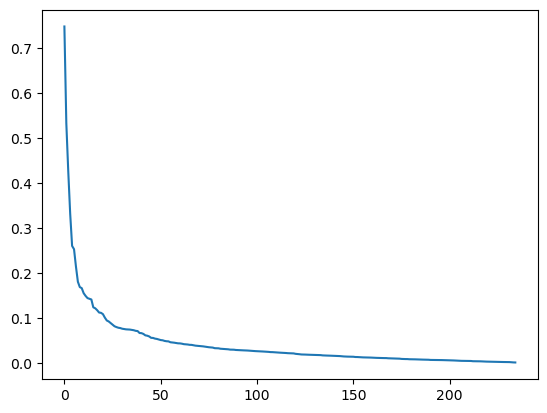

In [93]:
plt.plot(evals_LA11)

In [95]:
var_explained = np.sum(evals_LA11[0], 0) / np.sum(evals_LA11, 0)
print(var_explained)

0.07179078235058506


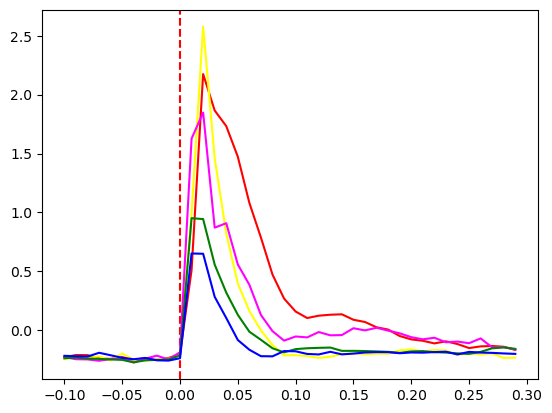

In [15]:
plot_one_component(theta_2_LA11, theta_4_LA11, theta_8_LA11, theta_16_LA11, theta_32_LA11, 0)

**Session II**

In [16]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA11_ses-2_behavior.nwb", mode='r')
mouse_LA11_ses_2_file = io.read()

In [17]:
theta_2_LA11_2, theta_4_LA11_2, theta_8_LA11_2, theta_16_LA11_2, theta_32_LA11_2, evals_LA11_2 = compute_mouse_thetas(mouse_LA11_ses_2_file)

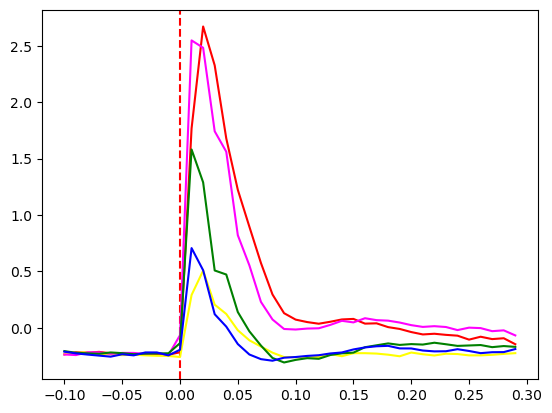

In [18]:
plot_one_component(theta_2_LA11_2, theta_4_LA11_2, theta_8_LA11_2, theta_16_LA11_2, theta_32_LA11_2, 0)

**Session III**

In [19]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA11_ses-3_behavior.nwb", mode='r')
mouse_LA11_ses_3_file = io.read()

In [20]:
theta_2_LA11_3, theta_4_LA11_3, theta_8_LA11_3, theta_16_LA11_3, theta_32_LA11_3, evals_LA11_3 = compute_mouse_thetas(mouse_LA11_ses_3_file)

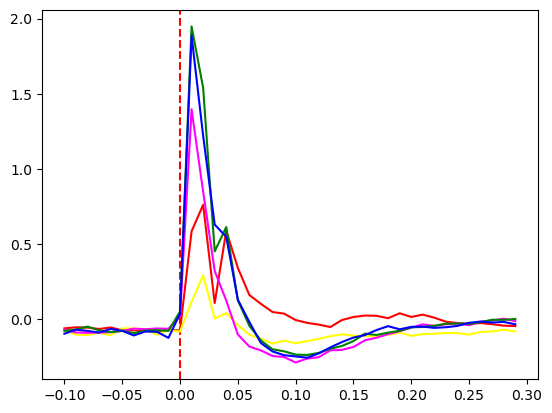

In [21]:
plot_one_component(theta_2_LA11_3, theta_4_LA11_3, theta_8_LA11_3, theta_16_LA11_3, theta_32_LA11_3, 0)

**Session VI**

In [22]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA11_ses-4_behavior.nwb", mode='r')
mouse_LA11_ses_4_file = io.read()

In [23]:
theta_2_LA11_4, theta_4_LA11_4, theta_8_LA11_4, theta_16_LA11_4, theta_32_LA11_4, evals_LA11_4 = compute_mouse_thetas(mouse_LA11_ses_4_file)

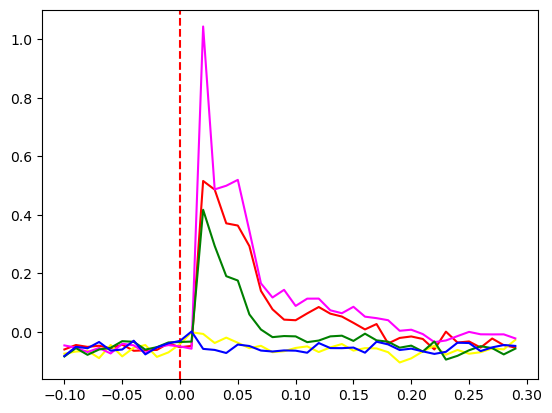

In [24]:
plot_one_component(theta_2_LA11_4, theta_4_LA11_4, theta_8_LA11_4, theta_16_LA11_4, theta_32_LA11_4, 0)

### Average Theta

In [25]:
average_theta_2_LA11 = (theta_2_LA11 + theta_2_LA11_2 + theta_2_LA11_3 + theta_2_LA11_4) / 4
average_theta_4_LA11 = (theta_4_LA11 + theta_4_LA11_2 + theta_4_LA11_3 + theta_4_LA11_4) / 4
average_theta_8_LA11 = (theta_8_LA11 + theta_8_LA11_2 + theta_8_LA11_3 + theta_8_LA11_4) / 4
average_theta_16_LA11 = (theta_16_LA11 + theta_16_LA11_2 + theta_16_LA11_3 + theta_16_LA11_4) / 4
average_theta_32_LA11 = (theta_32_LA11 + theta_32_LA11_2 + theta_32_LA11_3 + theta_32_LA11_4) / 4

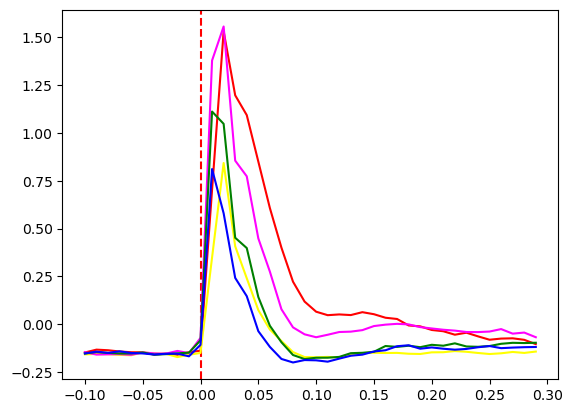

In [26]:
plot_one_component(average_theta_2_LA11, average_theta_4_LA11, average_theta_8_LA11, average_theta_16_LA11, average_theta_32_LA11, 0)

## Mouse LA9

**Session 1**

In [27]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA9_ses-1_behavior.nwb", mode='r')
mouse_LA9_ses_1_file = io.read()

In [28]:
theta_2_LA9, theta_4_LA9, theta_8_LA9, theta_16_LA9, theta_32_LA9, evals_LA9 = compute_mouse_thetas(mouse_LA9_ses_1_file)

**Session 2**

In [29]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA9_ses-3_behavior.nwb", mode='r')
mouse_LA9_ses_2_file = io.read()

In [30]:
theta_2_LA9_2, theta_4_LA9_2, theta_8_LA9_2, theta_16_LA9_2, theta_32_LA9_2, evals_LA9_2 = compute_mouse_thetas(mouse_LA9_ses_2_file)

**Session 3**

In [31]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA9_ses-4_behavior.nwb", mode='r')
mouse_LA9_ses_3_file = io.read()

In [32]:
theta_2_LA9_3, theta_4_LA9_3, theta_8_LA9_3, theta_16_LA9_3, theta_32_LA9_3, evals_LA9_3 = compute_mouse_thetas(mouse_LA9_ses_3_file)

**Session 4**

In [33]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA9_ses-5_behavior.nwb", mode='r')
mouse_LA9_ses_4_file = io.read()

In [34]:
theta_2_LA9_4, theta_4_LA9_4, theta_8_LA9_4, theta_16_LA9_4, theta_32_LA9_4, evals_LA9_4 = compute_mouse_thetas(mouse_LA9_ses_4_file)

### Average

In [35]:
average_theta_2_LA9 = (theta_2_LA9 + theta_2_LA9_2 + theta_2_LA9_3 + theta_2_LA9_4) / 4
average_theta_4_LA9 = (theta_4_LA9 + theta_4_LA9_2 + theta_4_LA9_3 + theta_4_LA9_4) / 4
average_theta_8_LA9 = (theta_8_LA9 + theta_8_LA9_2 + theta_8_LA9_3 + theta_8_LA9_4) / 4
average_theta_16_LA9 = (theta_16_LA9 + theta_16_LA9_2 + theta_16_LA9_3 + theta_16_LA9_4) / 4
average_theta_32_LA9 = (theta_32_LA9 + theta_32_LA9_2 + theta_32_LA9_3 + theta_32_LA9_4) / 4

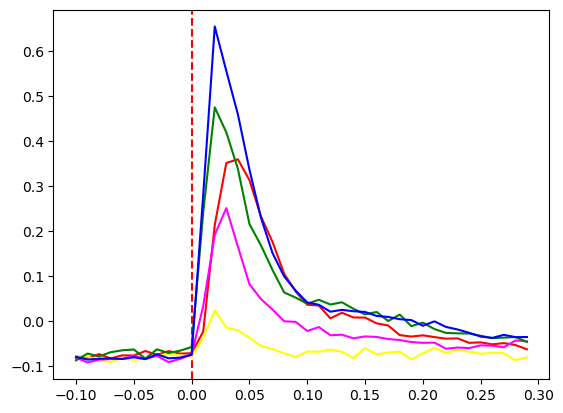

In [36]:
plot_one_component(average_theta_2_LA9, average_theta_4_LA9, average_theta_8_LA9, average_theta_16_LA9, average_theta_32_LA9, 0)

### Mouse LA8

**Session 1**

In [37]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA8_ses-1_behavior.nwb", mode='r')
mouse_LA8_ses_1_file = io.read()

In [38]:
theta_2_LA8, theta_4_LA8, theta_8_LA8, theta_16_LA8, theta_32_LA8, evals_LA8 = compute_mouse_thetas(mouse_LA8_ses_1_file)

**Session 2**

In [40]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA8_ses-2_behavior.nwb", mode='r')
mouse_LA8_ses_2_file = io.read()

In [41]:
theta_2_LA8_2, theta_4_LA8_2, theta_8_LA8_2, theta_16_LA8_2, theta_32_LA8_2, evals_LA8_2 = compute_mouse_thetas(mouse_LA8_ses_2_file)

### Average

In [43]:
average_theta_2_LA8 = (theta_2_LA8 + theta_2_LA8_2) / 2
average_theta_4_LA8 = (theta_4_LA8 + theta_4_LA8_2) / 2
average_theta_8_LA8 = (theta_8_LA8 + theta_8_LA8_2) / 2
average_theta_16_LA8 = (theta_16_LA8 + theta_16_LA8_2) / 2
average_theta_32_LA8 = (theta_32_LA8 + theta_32_LA8_2) / 2

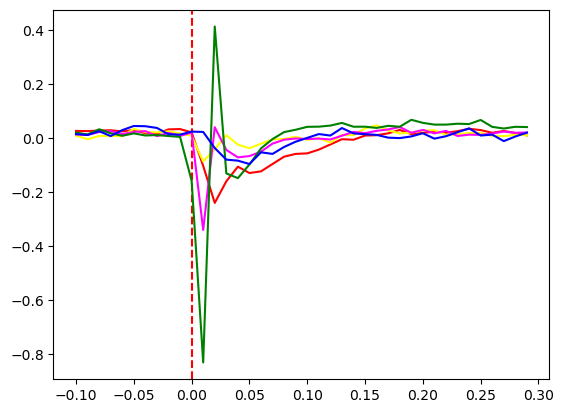

In [44]:
plot_one_component(average_theta_2_LA8, average_theta_4_LA8, average_theta_8_LA8, average_theta_16_LA8, average_theta_32_LA8, 0)

## Mouse LA3

In [45]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA3_ses-3_behavior.nwb", mode='r')
mouse_LA3_ses_1_file = io.read()

In [46]:
theta_2_LA3, theta_4_LA3, theta_8_LA3, theta_16_LA3, theta_32_LA3, evals_LA3 = compute_mouse_thetas(mouse_LA3_ses_1_file)

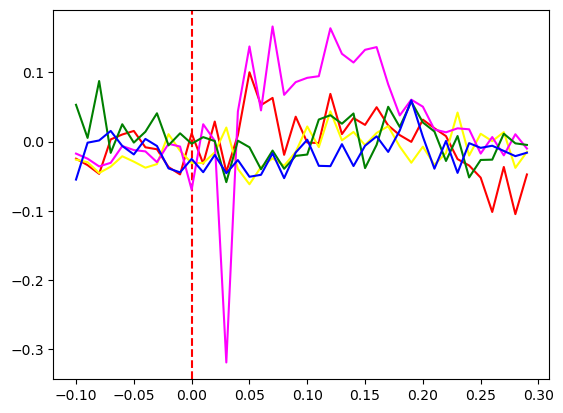

In [47]:
plot_one_component(theta_2_LA3, theta_4_LA3, theta_8_LA3, theta_16_LA3, theta_32_LA3, 0)

## Mouse LA12

**Session 1**

In [48]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA12_ses-1_behavior.nwb", mode='r')
mouse_LA12_ses_1_file = io.read()

In [49]:
theta_2_LA12, theta_4_LA12, theta_8_LA12, theta_16_LA12, theta_32_LA12, evals_LA12 = compute_mouse_thetas(mouse_LA12_ses_1_file)

**Session 2**

In [50]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA12_ses-2_behavior.nwb", mode='r')
mouse_LA12_ses_2_file = io.read()

In [51]:
theta_2_LA12_2, theta_4_LA12_2, theta_8_LA12_2, theta_16_LA12_2, theta_32_LA12_2, evals_LA12_2 = compute_mouse_thetas(mouse_LA12_ses_2_file)

**Session 3**

In [52]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA12_ses-3_behavior.nwb", mode='r')
mouse_LA12_ses_3_file = io.read()

In [55]:
theta_2_LA12_3, theta_4_LA12_3, theta_8_LA12_3, theta_16_LA12_3, theta_32_LA12_3, evals_LA12_3 = compute_mouse_thetas(mouse_LA12_ses_3_file)

**Session 4**

In [75]:
io = NWBHDF5IO("C:/Users/evleb/Downloads/sub-LA12_ses-4_behavior.nwb", mode='r')
mouse_LA12_ses_4_file = io.read()

In [92]:
theta_2_LA12_4, theta_4_LA12_4, theta_8_LA12_4, theta_16_LA12_4, theta_32_LA12_4, evals_LA12_4 = compute_mouse_thetas(mouse_LA12_ses_4_file)

### Average

In [77]:
average_theta_2_LA12 = (theta_2_LA12 + theta_2_LA12_2 + theta_2_LA12_3 + theta_2_LA12_4) / 4
average_theta_4_LA12 = (theta_4_LA12 + theta_4_LA12_2 + theta_4_LA12_3 + theta_4_LA12_4) / 4
average_theta_8_LA12 = (theta_8_LA12 + theta_8_LA12_2 + theta_8_LA12_3 + theta_8_LA12_4) / 4
average_theta_16_LA12 = (theta_16_LA12 + theta_16_LA12_2 + theta_16_LA12_3 + theta_16_LA12_4) / 4
average_theta_32_LA12 = (theta_32_LA12 + theta_32_LA12_2 + theta_32_LA12_3 + theta_32_LA12_4) / 4

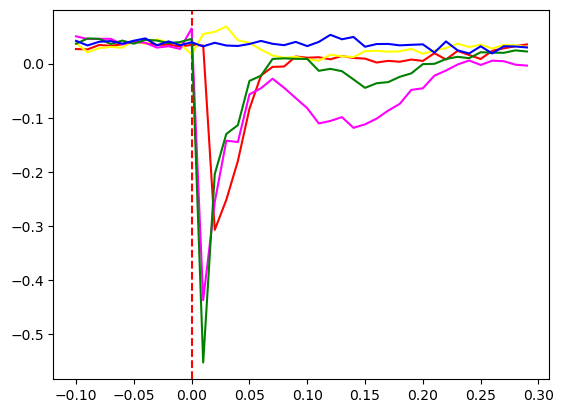

In [78]:
plot_one_component(average_theta_2_LA12, average_theta_4_LA12, average_theta_8_LA12, average_theta_16_LA12, average_theta_32_LA12, 0)

## Overall average

In [84]:
average_theta_2 = (average_theta_2_LA11 + average_theta_2_LA9 + average_theta_2_LA8 + theta_2_LA3 + average_theta_2_LA12) / 5
average_theta_4 = (average_theta_4_LA11 + average_theta_4_LA9 + average_theta_4_LA8 + theta_4_LA3 + average_theta_4_LA12) / 5
average_theta_8 = (average_theta_8_LA11 + average_theta_8_LA9 + average_theta_8_LA8 + theta_8_LA3 + average_theta_8_LA12) / 5
average_theta_16 = (average_theta_16_LA11 + average_theta_16_LA9 + average_theta_16_LA8 + theta_16_LA3 + average_theta_16_LA12) / 5
average_theta_32 = (average_theta_32_LA11 + average_theta_32_LA9 + average_theta_32_LA8 + theta_32_LA3 + average_theta_32_LA12) / 5

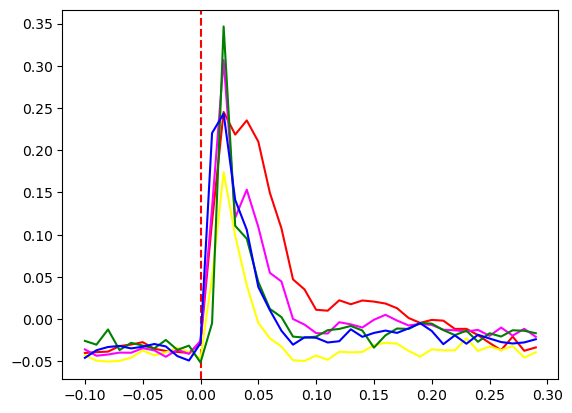

In [85]:
plot_one_component(average_theta_2, average_theta_4, average_theta_8, average_theta_16, average_theta_32, 0)

## Comparison of peaks

In [99]:
def get_peak(theta):
    peak_theta = np.max(theta[:, 0])
    peak_time = round(np.argmax(theta[:, 0]) * 0.01 - 0.1, 2)
    return peak_theta, peak_time

In [100]:
peak_theta_2, peak_time_2 = get_peak(average_theta_2)
peak_theta_4, peak_time_4 = get_peak(average_theta_4)
peak_theta_8, peak_time_8 = get_peak(average_theta_8)
peak_theta_16, peak_time_16 = get_peak(average_theta_16)
peak_theta_32, peak_time_32 = get_peak(average_theta_32)

In [101]:
print("Peak values: ", peak_theta_2, peak_theta_4, peak_theta_8, peak_theta_16, peak_theta_32)
print("Peak times: ", peak_time_2, peak_time_4, peak_time_8, peak_time_16, peak_time_32)

Peak values:  0.2453350269895592 0.17388835025236776 0.30676480744535983 0.3465176134484306 0.24339926839819753
Peak times:  0.02 0.02 0.02 0.02 0.02
